<a href="https://colab.research.google.com/github/aishasaidd2026/AishaDL-Project/blob/main/AishaDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# 2. LOAD & PREPROCESS DATA
# MNIST: 70,000 grayscale images (28x28) of handwritten digits
# Source: tensorflow.keras.datasets (auto-downloaded)
# Original: LeCun et al., 1998 — http://yann.lecun.com/exdb/mnist/

(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32')  / 255.

# Reshape to (samples, height, width, channels)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples    : {x_test.shape[0]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples    : 10000


In [ ]:
# 3A. ADD GAUSSIAN NOISE
noise_factor = 0.5

x_train_noisy_g = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy_g  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

# Clip to valid range [0, 1]
x_train_noisy_g = np.clip(x_train_noisy_g, 0., 1.)
x_test_noisy_g  = np.clip(x_test_noisy_g,  0., 1.)

print("Gaussian noise added.")

Gaussian noise added.


In [ ]:
# 3B. ADD SALT-AND-PEPPER NOISE
def add_salt_pepper(images, amount=0.05):
    """Add salt-and-pepper noise to a batch of images."""
    noisy = np.copy(images)
    num_salt   = int(amount * 28 * 28 * 0.5)
    num_pepper = int(amount * 28 * 28 * 0.5)
    for img in noisy:
        # Salt — white pixels
        coords = [np.random.randint(0, 28, num_salt) for _ in range(2)]
        img[coords[0], coords[1]] = 1.0
        # Pepper — black pixels
        coords = [np.random.randint(0, 28, num_pepper) for _ in range(2)]
        img[coords[0], coords[1]] = 0.0
    return noisy

x_test_noisy_sp = add_salt_pepper(x_test.copy(), amount=0.05)

print("Salt-and-pepper noise added.")

Salt-and-pepper noise added.


In [ ]:
# 4. BUILD CONVOLUTIONAL AUTOENCODER
input_img = Input(shape=(28, 28, 1), name='input')

# --- Encoder ---
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)       # 14x14x32
x = Conv2D(16, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
encoded = MaxPooling2D((2, 2), padding='same', name='bottleneck')(x) # 7x7x16

# --- Decoder ---
x = Conv2D(16, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded)
x = UpSampling2D((2, 2), name='dec_up1')(x)                          # 14x14x16
x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
x = UpSampling2D((2, 2), name='dec_up2')(x)                          # 28x28x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x)

autoencoder = Model(input_img, decoded, name='ConvAutoencoder')
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Print model summary
autoencoder.summary()


Model: "ConvAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. TRAIN MODEL
print("\nTraining model...")

history = autoencoder.fit(
    x_train_noisy_g, x_train,          # Input: noisy | Target: clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_g, x_test),
    verbose=1
)

print("Training complete.")


Training model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 264ms/step - loss: 0.1818 - val_loss: 0.1238
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 268ms/step - loss: 0.1190 - val_loss: 0.1136
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.1128 - val_loss: 0.1097
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 258ms/step - loss: 0.1096 - val_loss: 0.1073
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 260ms/step - loss: 0.1075 - val_loss: 0.1056
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 259ms/step - loss: 0.1059 - val_loss: 0.1045
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 259ms/step - loss: 0.1046 - val_loss: 0.1031
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 261ms/step - loss: 0.1036 - val_loss: 0.1029
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 258ms/step - loss: 0.1027 - val_loss: 0.1013
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 152s 281ms/step - loss: 0.1020 - val_loss: 0.1009
Training complete.


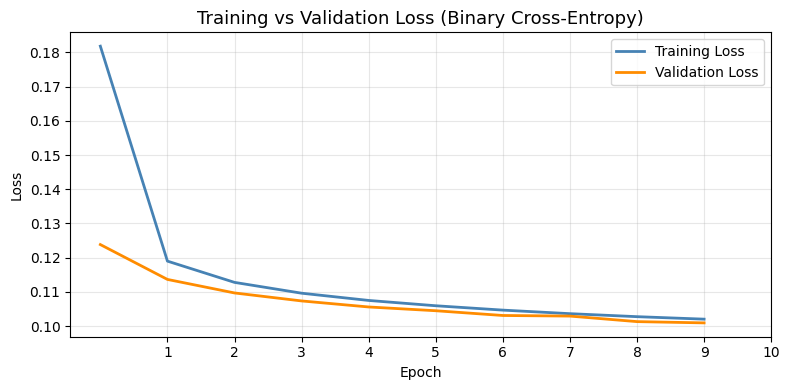

Loss curve saved as 'loss_curve.png'


In [ ]:
# 6. PLOT TRAINING LOSS CURVE
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
plt.title('Training vs Validation Loss (Binary Cross-Entropy)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved as 'loss_curve.png'")

In [ ]:
# 7. PREDICT — GAUSSIAN NOISE
decoded_gaussian = autoencoder.predict(x_test_noisy_g, verbose=0)

In [ ]:
# 8. PREDICT — SALT & PEPPER NOISE
decoded_sp = autoencoder.predict(x_test_noisy_sp, verbose=0)

In [ ]:
# 9. COMPUTE PSNR & SSIM METRICS
psnr_noisy_g,   psnr_denoised_g  = [], []
ssim_noisy_g,   ssim_denoised_g  = [], []
psnr_noisy_sp,  psnr_denoised_sp = [], []
ssim_noisy_sp,  ssim_denoised_sp = [], []

for i in range(len(x_test)):
    clean    = x_test[i].reshape(28, 28)
    n_gauss  = x_test_noisy_g[i].reshape(28, 28)
    d_gauss  = decoded_gaussian[i].reshape(28, 28)
    n_sp     = x_test_noisy_sp[i].reshape(28, 28)
    d_sp     = decoded_sp[i].reshape(28, 28)

    psnr_noisy_g.append(psnr(clean, n_gauss, data_range=1.0))
    psnr_denoised_g.append(psnr(clean, d_gauss, data_range=1.0))
    ssim_noisy_g.append(ssim(clean, n_gauss, data_range=1.0))
    ssim_denoised_g.append(ssim(clean, d_gauss, data_range=1.0))

    psnr_noisy_sp.append(psnr(clean, n_sp, data_range=1.0))
    psnr_denoised_sp.append(psnr(clean, d_sp, data_range=1.0))
    ssim_noisy_sp.append(ssim(clean, n_sp, data_range=1.0))
    ssim_denoised_sp.append(ssim(clean, d_sp, data_range=1.0))

# Print metrics table
print("\n" + "=" * 55)
print(f"{'Metric':<22} {'Noisy':>10} {'Denoised':>10}")
print("=" * 55)
print("--- Gaussian Noise ---")
print(f"{'PSNR (dB)':<22} {np.mean(psnr_noisy_g):>10.2f} {np.mean(psnr_denoised_g):>10.2f}")
print(f"{'SSIM':<22} {np.mean(ssim_noisy_g):>10.4f} {np.mean(ssim_denoised_g):>10.4f}")
print("--- Salt & Pepper Noise ---")
print(f"{'PSNR (dB)':<22} {np.mean(psnr_noisy_sp):>10.2f} {np.mean(psnr_denoised_sp):>10.2f}")
print(f"{'SSIM':<22} {np.mean(ssim_noisy_sp):>10.4f} {np.mean(ssim_denoised_sp):>10.4f}")
print("=" * 55)


Metric                      Noisy   Denoised
--- Gaussian Noise ---
PSNR (dB)                    9.37      19.32
SSIM                       0.3746     0.8427
--- Salt & Pepper Noise ---
PSNR (dB)                   16.49      22.02
SSIM                       0.7307     0.9208


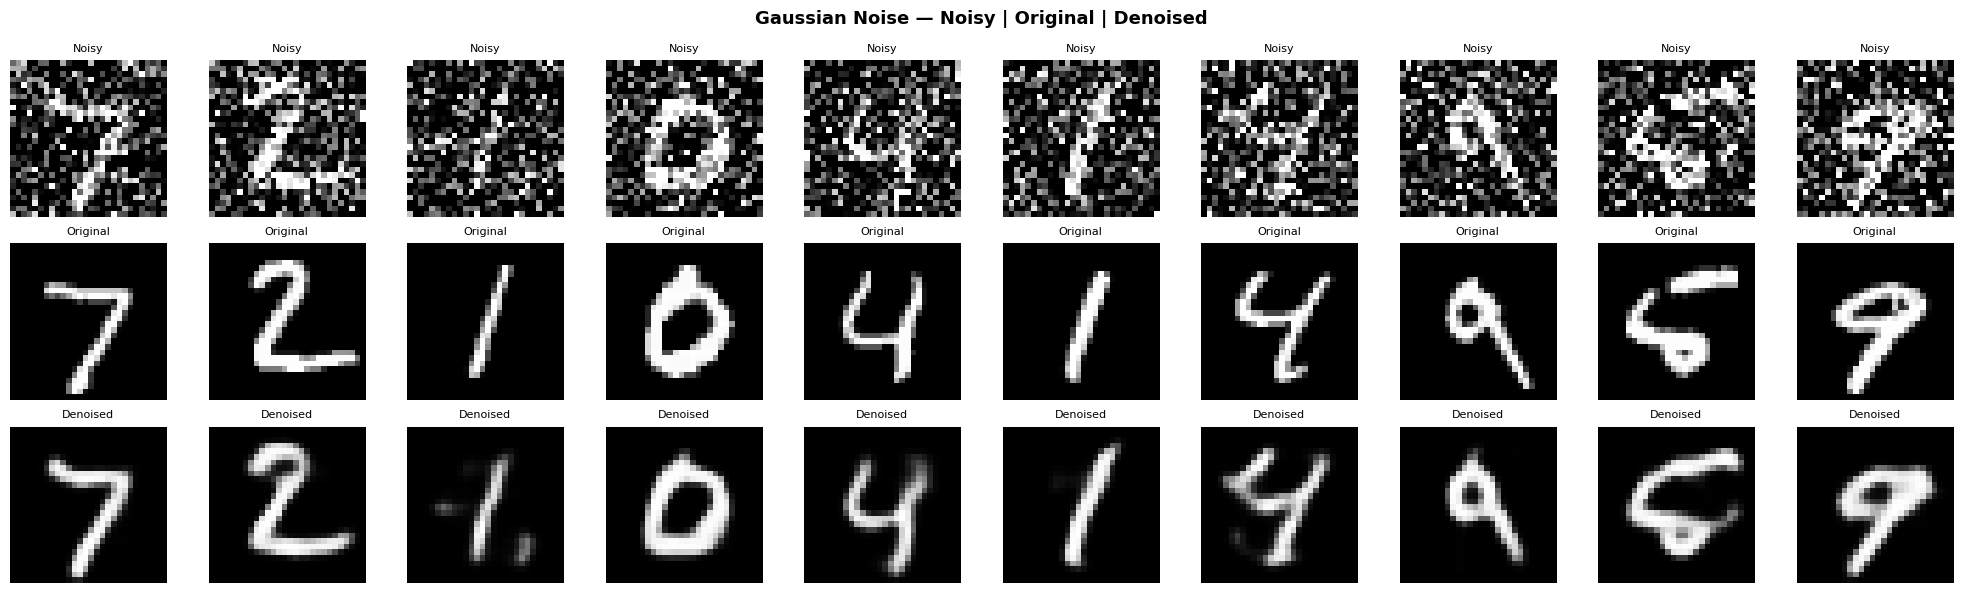

Gaussian visualization saved as 'gaussian_denoising.png'


In [ ]:
# 10. VISUALIZATION — GAUSSIAN NOISE
n = 10
fig, axes = plt.subplots(3, n, figsize=(20, 6))

for i in range(n):
    axes[0, i].imshow(x_test_noisy_g[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("Noisy", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Original", fontsize=8)
    axes[1, i].axis('off')

    axes[2, i].imshow(decoded_gaussian[i].reshape(28, 28), cmap='gray')
    axes[2, i].set_title("Denoised", fontsize=8)
    axes[2, i].axis('off')

plt.suptitle('Gaussian Noise — Noisy | Original | Denoised', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gaussian_denoising.png', dpi=150)
plt.show()
print("Gaussian visualization saved as 'gaussian_denoising.png'")



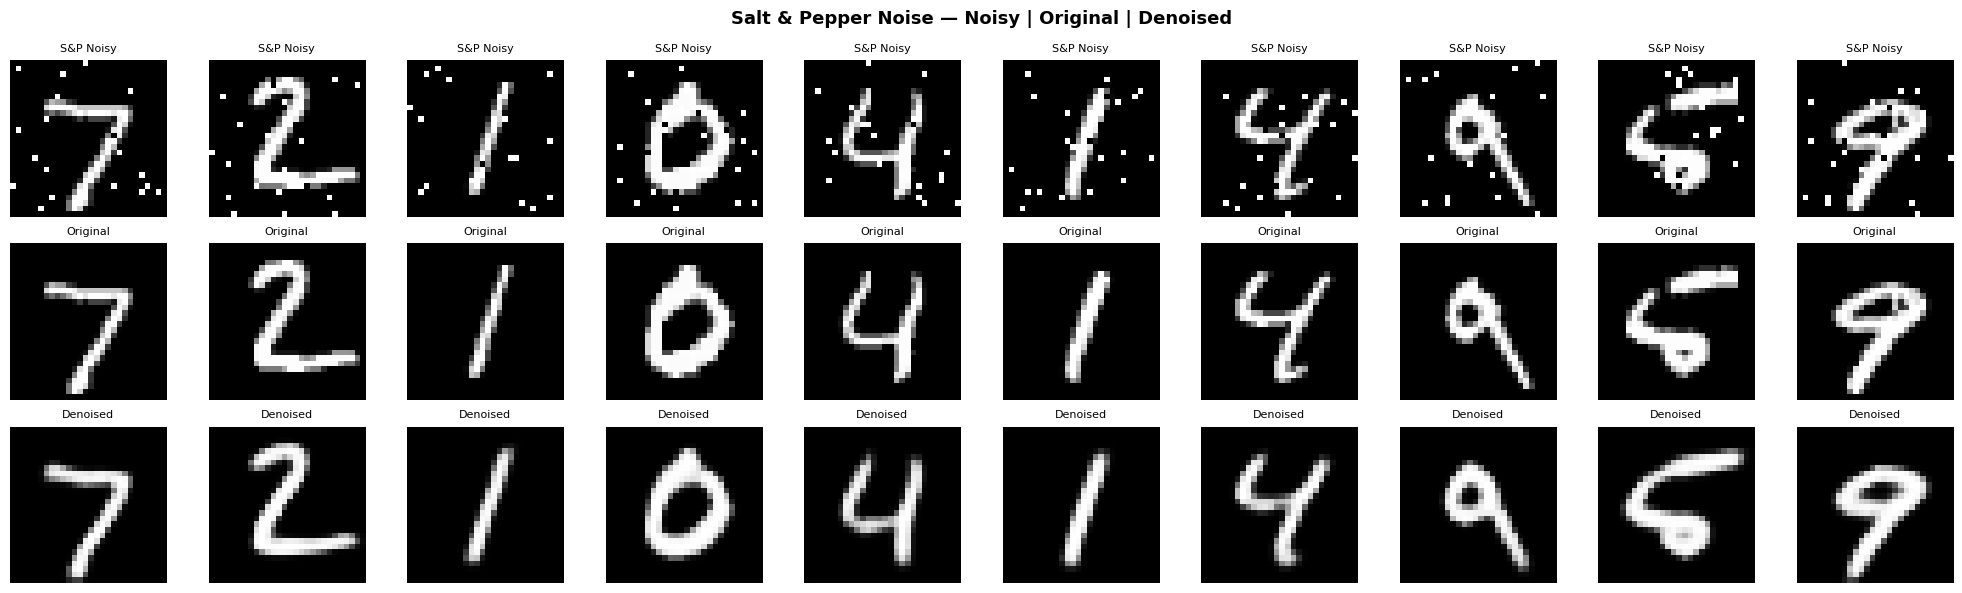

Salt & pepper visualization saved as 'saltpepper_denoising.png'


In [ ]:
# 11. VISUALIZATION — SALT & PEPPER NOISE
fig, axes = plt.subplots(3, n, figsize=(20, 6))

for i in range(n):
    axes[0, i].imshow(x_test_noisy_sp[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("S&P Noisy", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Original", fontsize=8)
    axes[1, i].axis('off')

    axes[2, i].imshow(decoded_sp[i].reshape(28, 28), cmap='gray')
    axes[2, i].set_title("Denoised", fontsize=8)
    axes[2, i].axis('off')

plt.suptitle('Salt & Pepper Noise — Noisy | Original | Denoised', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('saltpepper_denoising.png', dpi=150)
plt.show()
print("Salt & pepper visualization saved as 'saltpepper_denoising.png'")


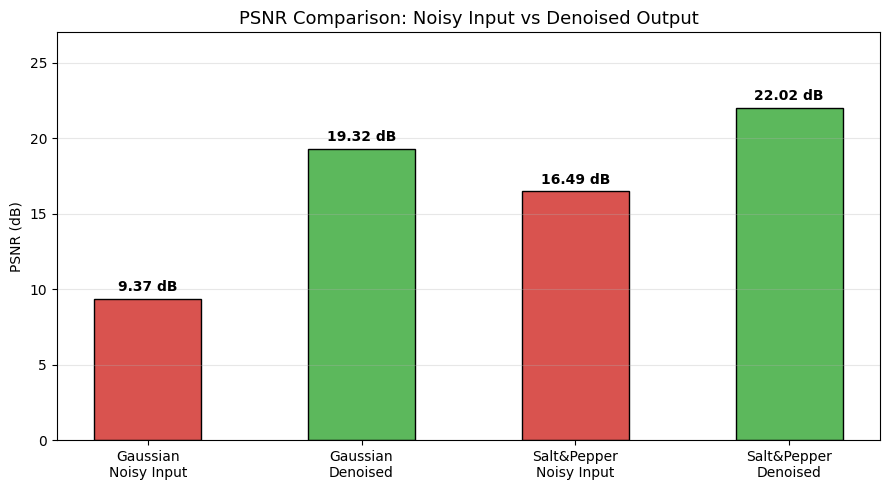

PSNR chart saved as 'psnr_comparison.png'

Done! All outputs saved.
Files generated:
  - loss_curve.png
  - gaussian_denoising.png
  - saltpepper_denoising.png
  - psnr_comparison.png


In [ ]:
# 12. PSNR BAR CHART (for report)
categories = ['Gaussian\nNoisy Input', 'Gaussian\nDenoised', 'Salt&Pepper\nNoisy Input', 'Salt&Pepper\nDenoised']
psnr_values = [
    np.mean(psnr_noisy_g),
    np.mean(psnr_denoised_g),
    np.mean(psnr_noisy_sp),
    np.mean(psnr_denoised_sp)
]
colors = ['#d9534f', '#5cb85c', '#d9534f', '#5cb85c']

plt.figure(figsize=(9, 5))
bars = plt.bar(categories, psnr_values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, psnr_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f} dB', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('PSNR Comparison: Noisy Input vs Denoised Output', fontsize=13)
plt.ylabel('PSNR (dB)')
plt.ylim(0, max(psnr_values) + 5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('psnr_comparison.png', dpi=150)
plt.show()
print("PSNR chart saved as 'psnr_comparison.png'")

print("\nDone! All outputs saved.")
print("Files generated:")
print("  - loss_curve.png")
print("  - gaussian_denoising.png")
print("  - saltpepper_denoising.png")
print("  - psnr_comparison.png")
